# Buettner et al. (2015) – Computational analysis of cell-to-cell heterogeneity in single-cell RNA-sequencing data reveals hidden subpopulations of cells

The original paper can be found here: https://www.nature.com/articles/nbt.3102

__Abstract__: Recent technical developments have enabled the transcriptomes of hundreds of cells to be assayed in an unbiased manner, opening up the possibility that new subpopulations of cells can be found. However, the effects of potential confounding factors, such as the cell cycle, on the heterogeneity of gene expression and therefore on the ability to robustly identify subpopulations remain unclear. We present and validate a computational approach that uses latent variable models to account for such hidden factors. We show that our single-cell latent variable model (scLVM) allows the identification of otherwise undetectable subpopulations of cells that correspond to different stages during the differentiation of naive T cells into T helper 2 cells. Our approach can be used not only to identify cellular subpopulations but also to tease apart different sources of gene expression heterogeneity in single-cell transcriptomes.

**SC3: consensus clustering of single-cell RNA-seq data** by Kiselev et al. (2017) uses the Buettner et al. dataset to benchmark their clustering method SC3, which can be found here: https://www.nature.com/articles/nmeth.4236

Buettner et al. (2015) is an early single-cell RNA-seq dataset of mouse embryonic stem cells sorted by cell-cycle phase (G1, S, G2/M) via Hoechst/FACS. 
- Commonly used as a “3-class” benchmark for clustering/heterogeneity methods; labels are known. 
- Processed matrices and metadata (including phase labels) are on **ArrayExpress (E-MTAB-2805)**; many re-analyses also host ready-to-load H5AD/loom versions. Will take from https://www.ebi.ac.uk/biostudies/arrayexpress/studies/E-MTAB-2805

Compared to Yan et al. (2013), which tracks human embryonic developmental stages, Buettner focuses on mouse ESCs (embryonic stem cells) and cell-cycle variation—same early Smart-seq, different biological axis.

## 0. Imports & Set-Up:

In [179]:
from sklearn.cluster import AgglomerativeClustering, KMeans, SpectralClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import pairwise_distances, adjusted_rand_score
from sklearn.preprocessing import FunctionTransformer

from umap import UMAP

import numpy as np
import pandas as pd
import scanpy as sc

import matplotlib.pyplot as plt

from carve import CARVE
from carve.config import ValidatorConfig

In [180]:
%env PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning

env: PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning


---

## 1. Pre-Process the Data

1) read the three phase-specific matrices

In [194]:
# each file: rows = genes, cols = cells; first column is gene ids
dir = "../data/Buettner/"

def read_phase_table(path, phase):
    df = pd.read_csv(path, sep="\t", dtype=str)  # read as a regular table
    df = df.set_index(df.columns[0])  # set first column as index
    df_num = df.apply(pd.to_numeric, errors="coerce")  # keep only numeric columns (drop gene symbol / misc cols if present)
    df_num = df_num.loc[:, df_num.notna().any()].fillna(0.0)  # drop all-NaN columns (not expression), fill remaining NaNs with 0
    df_num.columns = [f"{phase}_{c}" for c in df_num.columns]  # prefix cell names with phase to ensure uniqueness
    
    return df_num

G1 = read_phase_table(f"{dir}G1_singlecells_counts.txt", "G1")
S = read_phase_table(f"{dir}S_singlecells_counts.txt", "S")
G2M = read_phase_table(f"{dir}G2M_singlecells_counts.txt", "G2M")

# union genes, concatenate cells
expr = pd.concat([G1, S, G2M], axis=1).fillna(0.0)   # genes x cells, numeric
print(expr.shape, "genes x cells")

(38390, 291) genes x cells


2) build cell metadata (obs)

In [195]:
phase = pd.concat([
    pd.Series("G1", index=G1.columns),
    pd.Series("S", index=S.columns),
    pd.Series("G2M", index=G2M.columns)
])

obs = pd.DataFrame({"phase": phase.astype("category")})
obs.index.name = "cell_id"
assert obs.shape[0] == expr.shape[1]

3) make AnnData 

In [196]:
adata = sc.AnnData(expr.T.astype(np.float32))  # cells x genes
adata.obs = obs.reindex(adata.obs_names)  # align

adata.layers["counts"] = adata.X.copy()

4) save for later reuse

In [197]:
adata.write(f"{dir}adata_buettner.h5ad")

# quick sanity checks
print(adata)
print(adata.obs["phase"].value_counts())

AnnData object with n_obs × n_vars = 291 × 38390
    obs: 'phase'
    layers: 'counts'
phase
G1     97
G2M    97
S      97
Name: count, dtype: int64


---

## 2. Analyse Data

In [198]:
# construct X (cells x genes) and y from adata
X = pd.DataFrame(adata.X, index=adata.obs_names, columns=adata.var_names)
label_key = 'phase'
y = adata.obs[label_key].values

X.shape, y.shape

((291, 38390), (291,))

In [199]:
print(f"np.unique(obs): {np.unique(obs)}")
print(f"len(np.unique(obs)): {len(np.unique(obs))}")

np.unique(obs): ['G1' 'G2M' 'S']
len(np.unique(obs)): 3


PCA plot of raw gene counts:

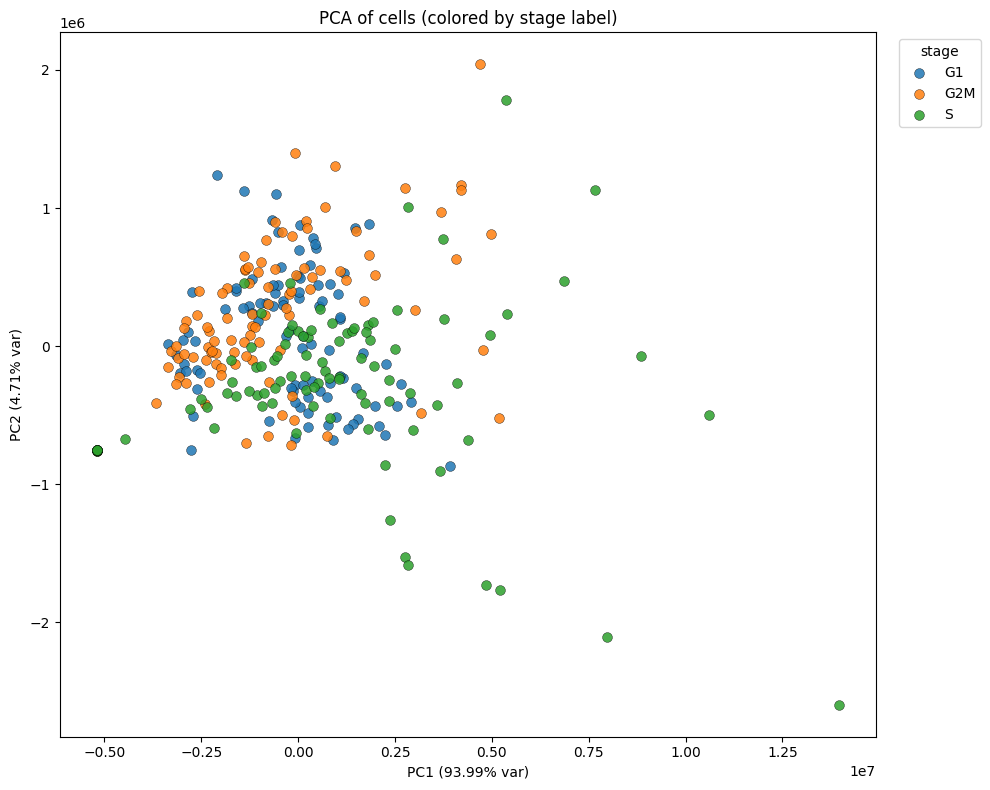

In [200]:
# PCA on cells (samples are columns of X) and scatter plot colored by y
pca = PCA(n_components=2)
pcs = pca.fit_transform(X)  # shape: (n_cells, 2)

pc_df = pd.DataFrame(pcs, index=X.index, columns=['PC1', 'PC2'])
pc_df['label'] = y

plt.figure(figsize=(10, 8))
labels = pd.Categorical(pc_df['label']).categories
cmap = plt.get_cmap('tab10')
color_map = {lab: cmap(i % 10) for i, lab in enumerate(labels)}

for lab in labels:
    sel = pc_df[pc_df['label'] == lab]
    plt.scatter(sel['PC1'], sel['PC2'], label=lab, color=color_map[lab], s=50, alpha=0.85, edgecolor='k', linewidth=0.3)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% var)")
plt.title("PCA of cells (colored by stage label)")
plt.legend(title='stage', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

Normalize and Select Highly-Variable Genes:

In [201]:
print(adata.obs.columns)

Index(['phase'], dtype='object')


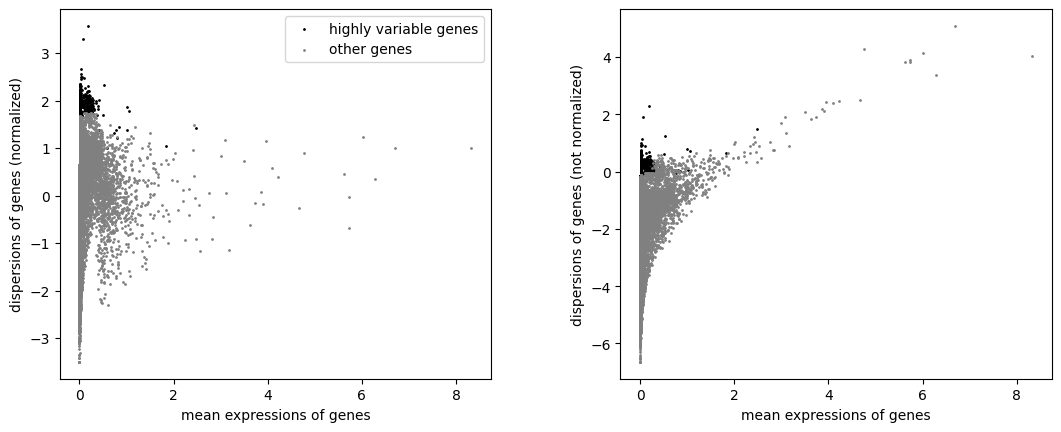

In [202]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=500, batch_key="phase", flavor='seurat')
sc.pl.highly_variable_genes(adata)

Subset to HVGs only:

In [203]:
adata = adata[:, adata.var["highly_variable"]].copy()

In [204]:
# Overwrite X and y using the (HVG-subset) adata
X = pd.DataFrame(adata.X, index=adata.obs_names, columns=adata.var_names)
label_key = 'phase'
y = adata.obs[label_key].values

print("X.shape:", X.shape)
print("y.shape:", y.shape)

X.shape: (291, 500)
y.shape: (291,)


PCA of log1p transformed 500 HVGs:

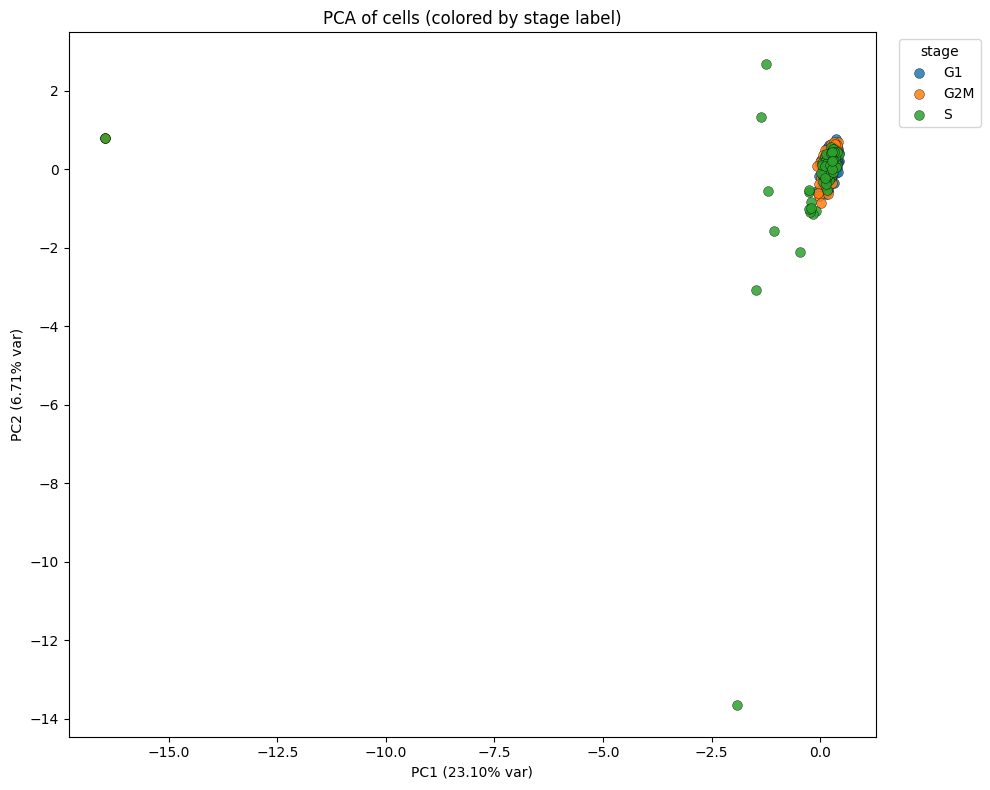

In [205]:
pca = PCA(n_components=2)
pcs = pca.fit_transform(X)

pc_df = pd.DataFrame(pcs, index=X.index, columns=['PC1', 'PC2'])
pc_df['label'] = y

plt.figure(figsize=(10, 8))
labels = pd.Categorical(pc_df['label']).categories
cmap = plt.get_cmap('tab10')
color_map = {lab: cmap(i % 10) for i, lab in enumerate(labels)}

for lab in labels:
    sel = pc_df[pc_df['label'] == lab]
    plt.scatter(sel['PC1'], sel['PC2'], label=lab, color=color_map[lab], s=50, alpha=0.85, edgecolor='k', linewidth=0.3)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% var)")
plt.title("PCA of cells (colored by stage label)")
plt.legend(title='stage', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

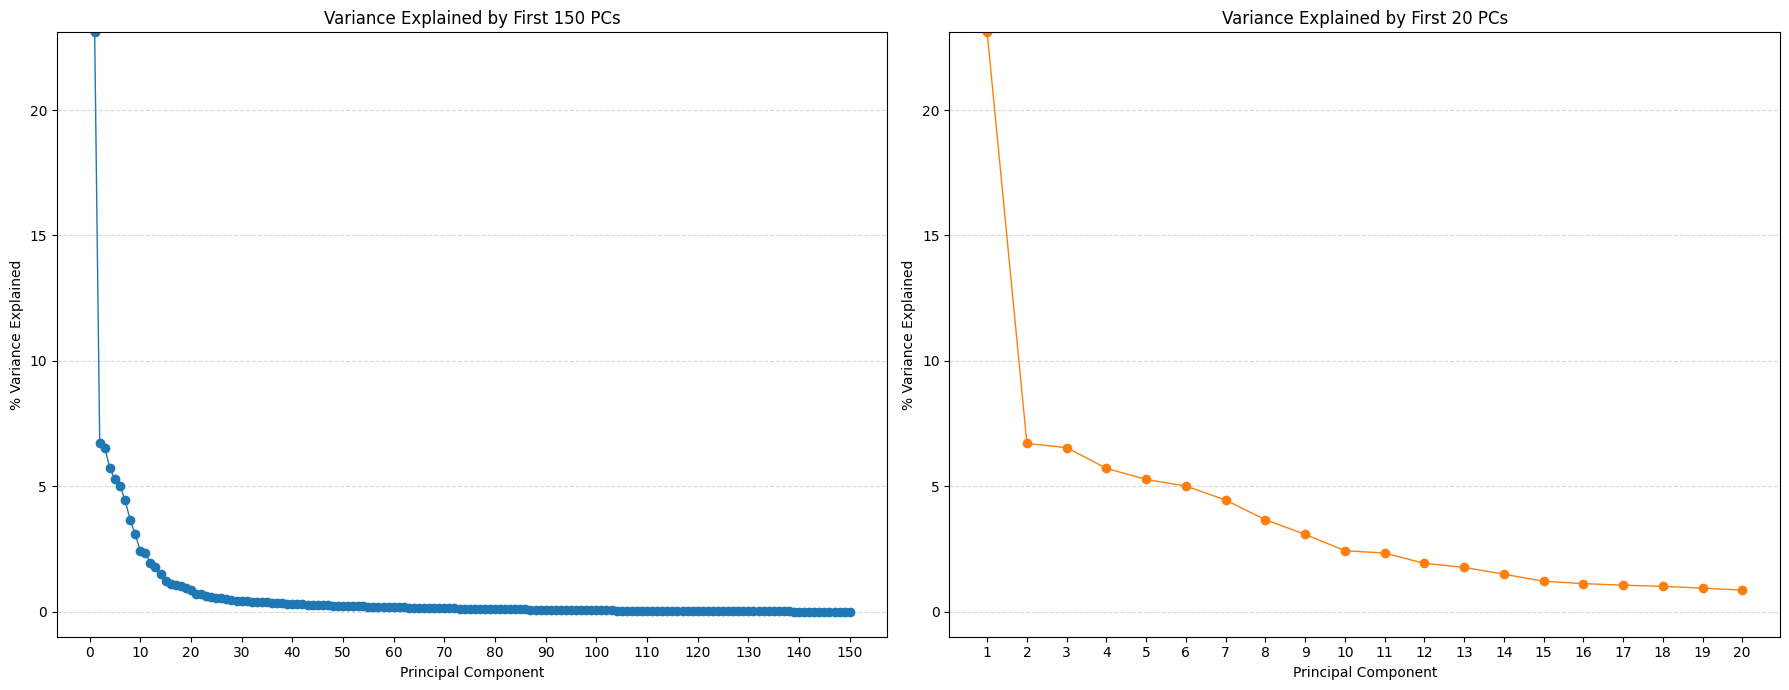

In [206]:
pca = PCA(n_components=150)
pcs = pca.fit_transform(X)

fig, ax = plt.subplots(1, 2, figsize=(18, 7))
ymin = min(pca.explained_variance_ratio_[:150] * 100).min() - 1
ymax = max(pca.explained_variance_ratio_[:150] * 100).max()
ax[0].set_ylim(ymin, ymax)
ax[1].set_ylim(ymin, ymax)

ax[0].plot(np.arange(1, 151), pca.explained_variance_ratio_[:150] * 100, marker='o', linewidth=1)
ax[0].set_xlabel('Principal Component')
ax[0].set_ylabel('% Variance Explained')
ax[0].set_title('Variance Explained by First 150 PCs')
ax[0].set_xticks(np.arange(0, 151, 10))
ax[0].grid(axis='y', linestyle='--', alpha=0.5)

ax[1].plot(np.arange(1, 21), pca.explained_variance_ratio_[:20] * 100, marker='o', linewidth=1, color='tab:orange')
ax[1].set_xlabel('Principal Component')
ax[1].set_ylabel('% Variance Explained')
ax[1].set_title('Variance Explained by First 20 PCs')
ax[1].set_xticks(np.arange(1, 21, 1))
ax[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Find largest drop in explained variance ratio between PCs ~12 and 20:

In [207]:
expl_var = pca.explained_variance_ratio_[:20] * 100
diffs = np.diff(expl_var)

drop_start = 12 - 1  # PC12 is index 11
drop_end = 20 - 1  # PC20 is index 19
drop_idx = np.argmin(diffs[drop_start:drop_end]) + drop_start

print(f"Largest drop between PC10 and PC20 is between PC{drop_idx+1} and PC{drop_idx+2}:")
print(f"Explained variance drops from {expl_var[drop_idx]:.2f}% to {expl_var[drop_idx+1]:.2f}% (Δ = {diffs[drop_idx]:.2f}%)")

Largest drop between PC10 and PC20 is between PC14 and PC15:
Explained variance drops from 1.50% to 1.22% (Δ = -0.28%)


In [208]:
explained_var_14 = pca.explained_variance_ratio_[:14].sum() * 100
print(f"Cumulative variance explained by the first 14 PCs: {explained_var_14:.2f}%")

Cumulative variance explained by the first 14 PCs: 73.57%


---

### Determine Pre-Processing Pipeline with CARVE:

In [171]:
norm_options = [
    (FunctionTransformer, {}), 
]

dr_options = [
    (PCA, {
        'n_components': [14]
    }),
    (TSNE, {
        'n_components': [2], 
        'perplexity': list(range(5, 30+1))
    }),
    (UMAP, {
        'n_components': [2], 
        'n_neighbors': list(range(5, 15+1)), 
        'min_dist': [0.1]
    }),
]

cfg = ValidatorConfig(
    X=X,
    K=5,
    B=100,
    norm_options=norm_options,
    dr_options=dr_options,
    ref_labels=y
)

val = CARVE(cfg)
val.validate(random_preprocess=True, random_state=42)

Grid configs:   0%|          | 0/36 [00:00<?, ?it/s]

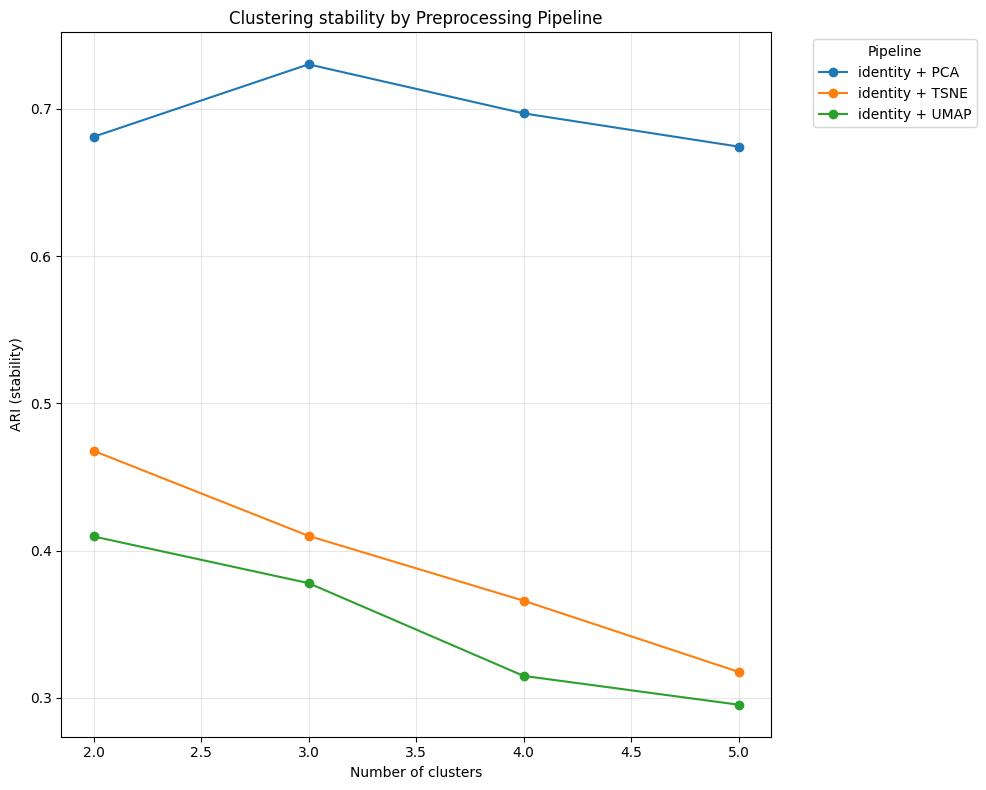

In [172]:
val.plot_preprocessing_results()

---
### Determine Optimal Clustering with CARVE:

In [173]:
pca = PCA(n_components=14)
X_log_pca = pca.fit_transform(X)
print("X_log_pca shape:", X_log_pca.shape)

X_log_pca shape: (291, 14)


In [174]:
cfg = ValidatorConfig(
    X=X_log_pca,
    K=5,
    B=100,
    ref_labels=y
)

val = CARVE(cfg)
val.validate(random_preprocess=False, random_state=42)

Grid configs:   0%|          | 0/36 [00:00<?, ?it/s]

In [175]:
val.plot_results(measure='s', rule='1se')

In [176]:
val.plot_results(measure='g', rule='1se')

/Users/kaiwycik/Documents/GitHub/ClusteringValidation/src/carve/_plotting.py:474: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



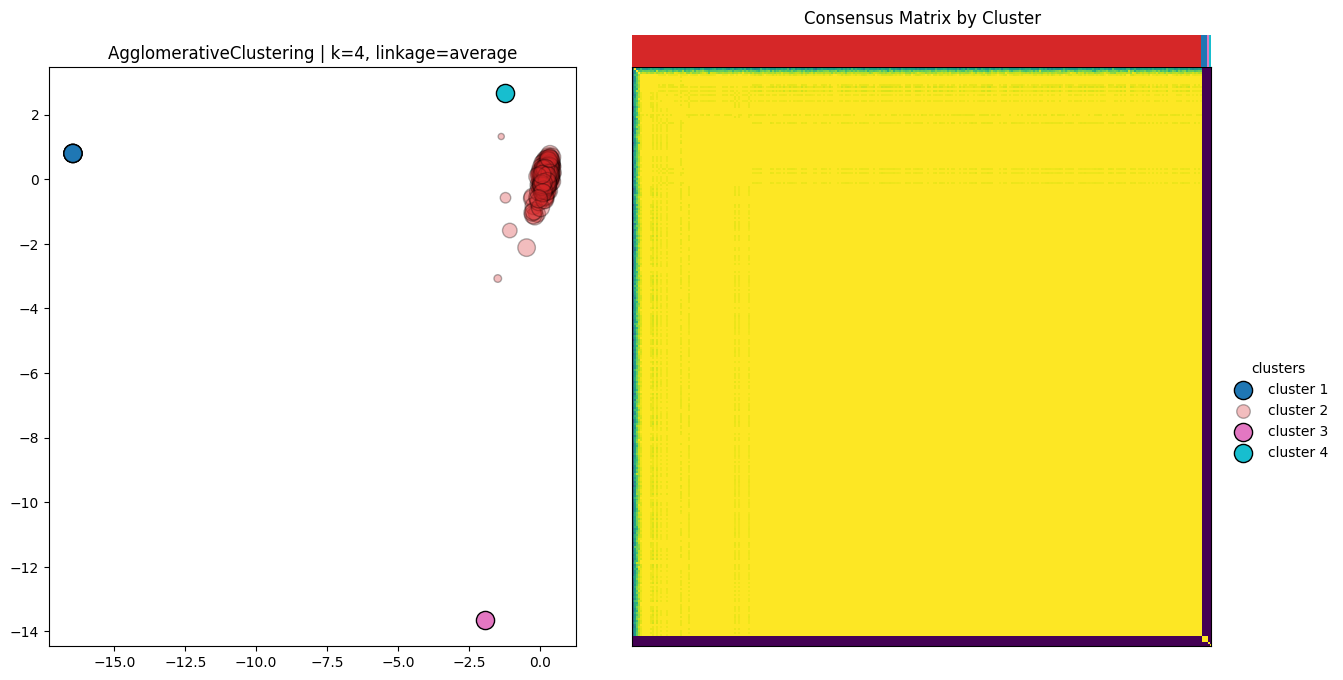

In [177]:
val.plot_consensus_clustering(k=4, figsize=(15, 8))

In [178]:
val.plot_clustering(k=4)

FigureWidget({
    'data': [{'customdata': {'bdata': ('AAAAAAAA8D8AAAAAAAAAAAAAAAAAAP' ... '56PEGt7z+VRevS6KTvP47jOI7jOO4/'),
                             'dtype': 'f8',
                             'shape': '286, 6'},
              'hovertemplate': ('sample %{customdata[0]}<br>clu' ... 'tomdata[5]:.4f}<extra></extra>'),
              'legendgroup': 'cluster-0',
              'marker': {'color': '#636EFA',
                         'line': {'color': 'black', 'width': 1.0},
                         'opacity': 0.3,
                         'size': {'bdata': ('Yder9T6pKkC9j/8tdKwqQE6MNeI9rC' ... 'BwArQqQIEDm+s3ripA/IaGn4C0KkA='),
                                  'dtype': 'f8'}},
              'mode': 'markers',
              'name': 'cluster 1',
              'showlegend': True,
              'type': 'scatter',
              'uid': 'c29c54b7-66c0-4abc-89ed-1d630d5087bd',
              'x': {'bdata': ('1PZvPmX4xz58s5k+jDURPkcGdD6ghV' ... '57aY09A0j3Pf2r1T3F8UK9IJaXPQ=='),
                 